# Room-Transition Heating Prediction vs PreHeat

This notebook reproduces (in miniature) the experiment comparing two occupancy-forecasting
methods for anticipatory residential heating:

- **Baseline**: a faithful reproduction of **PreHeat** (Scott et al. 2011) — a per-room K=5
  Hamming-distance nearest-neighbor predictor that forecasts future occupancy by averaging
  the same time-of-day-and-daytype outcome across the 5 historical days most similar (by
  Hamming distance on occupancy-so-far) to today.
- **Proposed method**: a **current-room-conditioned Markov room-transition predictor** — an
  order-1 slot-to-slot transition matrix (weekday/weekend split) augmented with an order-2
  last-two-slots context model that backs off to order-1 via additive smoothing when context
  evidence is sparse, propagated to longer horizons via closed-form transition-matrix powers.

Both predictors are driven through a shared **RC-network thermal simulator**
(`dT/dt = (Q_heater - U*(T-T_out) - sum_j K_ij*(T-T_j)) / C`) with a reactive-fallback comfort
guarantee, across 3 synthetic household topologies (3/4/5 rooms; linear/star/hallway-connected
graphs). Outputs are compared via per-room ROC curves and, at matched false-positive rates, via
a thermal-simulation gas-use proxy and miss-time (comfort) metric, with cross-topology
bootstrap 95% confidence intervals on the percentage energy savings of the transition
predictor vs. the PreHeat baseline.

No real multi-room occupancy dataset was available, so (per the original artifact's
fallback plan) a physics/behavior-calibrated **synthetic** occupant-trajectory generator is
used: a semi-Markov random walk over each topology's room graph with log-normal dwell-time
jitter, weekday/weekend anchor schedules, a regularity parameter, and injected sensor noise.

This notebook keeps the original script's logic essentially unchanged, split into cells with
explanatory markdown, and run at a reduced scale (fewer days / bootstrap resamples / lookaheads)
so it finishes quickly. The topology definitions (room graphs) are loaded from
`mini_demo_data.json` since the original script's own `make_topologies()` hardcodes them.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, matplotlib — pre-installed on Colab, install locally only (to match Colab's env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from __future__ import annotations

import gc
import json
import sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load data

`mini_demo_data.json` holds the 3 synthetic household topology definitions (room lists +
thermal-coupling adjacency + regularity) that the original script's `make_topologies()`
hardcodes. Loaded from GitHub with a local-file fallback so this works both on Colab and
locally, before/after the data file is pushed to the repo.

In [3]:
import os
import json

GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-ba45a6-transition-sequence-pre-heating-beats/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Loaded", len(data["topologies"]), "topology definitions:", [t["name"] for t in data["topologies"]])

Loaded 3 topology definitions: ['studio_linear_regular', 'apartment_star_mixed', 'house_5room_irregular']


## Configuration

All tunable parameters from the original script, gathered here. Starting at reduced scale
(fewer simulated days, fewer bootstrap resamples, fewer lookaheads/FPR targets) so the demo
finishes quickly. Set `N_DAYS=60`, `LOOKAHEADS=[15,30,45,60]`, `FPR_TARGETS=[0.05,0.10,0.20]`,
`N_BOOTSTRAP=500` to reproduce the original full-scale run.

In [5]:
# --- reduced-scale config (original values commented) ---
N_DAYS = 14                 # original: 60  (days simulated per topology)
LOOKAHEADS = [15, 30]       # original: [15, 30, 45, 60]  (minutes)
FPR_TARGETS = [0.10]        # original: [0.05, 0.10, 0.20]
N_BOOTSTRAP = 50            # original: 500

# --- unchanged simulation constants ---
SLOTS_PER_DAY = 96  # 15-min resolution
DT_MIN = 15.0
DT_HOURS = DT_MIN / 60.0
TARGET_TEMP = 20.0  # C, setpoint when heating is warranted
SETBACK_MISS_TOL = 1.0  # C below target while occupied counts as a "miss"
K_COUPLING = 30.0  # W/C, adjacent-room thermal coupling
RNG_SEED = 20260821

## 0. Synthetic occupancy / trajectory generation

Since no real multi-room occupancy dataset was available, occupant trajectories are generated
by a semi-Markov random walk over each topology's room graph: a "preferred" weekday/weekend
schedule anchors the regular component, a `regularity` parameter blends in uniformly-random
room choices, dwell durations get log-normal jitter, and 5-10% independent per-slot sensor
noise is injected. `Topology` objects are built here from the definitions in `data`
(loaded above) instead of the original script's hardcoded `make_topologies()`.

In [6]:
@dataclass
class Topology:
    name: str
    rooms: list[str]  # excludes "AWAY"
    adjacency: dict[str, list[str]]  # room -> neighbor rooms (thermal coupling)
    regularity: float  # 0=irregular (near-uniform transitions), 1=highly regular
    n_days: int = 60


def make_topologies() -> list[Topology]:
    """3 synthetic household topologies spanning room-count / adjacency / regularity."""
    return [
        Topology(name=t["name"], rooms=t["rooms"], adjacency=t["adjacency"], regularity=t["regularity"], n_days=N_DAYS)
        for t in data["topologies"]
    ]


AWAY = "AWAY"


def _room_index(topo: Topology) -> dict[str, int]:
    labels = [AWAY] + topo.rooms
    return {r: i for i, r in enumerate(labels)}


def _preferred_daily_schedule(rng: np.random.Generator, topo: Topology, daytype: str) -> list[tuple[str, float]]:
    """A loose 'preferred' sequence of (room, mean_dwell_minutes) anchoring the regular
    component of the semi-Markov walk. Weekday vs weekend differ (PreHeat's own split)."""
    rooms = topo.rooms
    if daytype == "weekday":
        anchors = [
            (AWAY, 0, 420),  # midnight-7am: asleep -> counted as "bedroom" not away; handled below
            ("bedroom", 0, 420),
            ("kitchen", 420, 60),
            (AWAY, 480, 540),  # away at work
            ("kitchen", 1020, 60),
            ("living", 1080, 300),
            ("bedroom", 1380, 60),
        ]
    else:
        anchors = [
            ("bedroom", 0, 480),
            ("kitchen", 480, 45),
            ("living", 525, 360),
            ("kitchen", 885, 60),
            ("living", 945, 300),
            (AWAY, 1245, 120),
            ("bedroom", 1365, 75),
        ]
    out = []
    for room, start_min, dur_min in anchors:
        if room != AWAY and room not in rooms:
            room = rooms[hash(room) % len(rooms)]
        out.append((room, start_min, dur_min))
    return out


def generate_topology_data(topo: Topology, seed: int) -> dict:
    """Semi-Markov random walk occupant simulator -> per-room binary occupancy matrices."""
    rng = np.random.default_rng(seed)
    idx = _room_index(topo)
    n_labels = len(idx)
    n_rooms = len(topo.rooms)

    occ = {r: np.zeros((topo.n_days, SLOTS_PER_DAY), dtype=np.int8) for r in topo.rooms}
    trajectories = []  # list of (daytype, [room_label per slot])
    daytypes = []

    for day in range(topo.n_days):
        dow = day % 7
        daytype = "weekend" if dow >= 5 else "weekday"
        schedule = _preferred_daily_schedule(rng, topo, daytype)
        # regular component: sample dwell durations around the anchor durations with
        # log-normal jitter; irregular component: with prob (1-regularity) at each
        # anchor, substitute a uniformly random room/duration instead.
        slots = np.empty(SLOTS_PER_DAY, dtype=object)
        cur_min = 0
        for anchor_i, (room, start_min, dur_min) in enumerate(schedule):
            if cur_min >= 1440:
                break
            use_regular = rng.random() < topo.regularity
            if not use_regular:
                room = rng.choice([AWAY] + topo.rooms)
                dur_min = max(15.0, rng.lognormal(mean=np.log(90), sigma=0.9))
            else:
                jitter = rng.lognormal(mean=0.0, sigma=0.25)
                dur_min = max(15.0, dur_min * jitter if dur_min > 0 else 30.0)
            end_min = min(1440, cur_min + dur_min)
            s0, s1 = int(cur_min // DT_MIN), int(end_min // DT_MIN)
            s1 = max(s1, s0 + 1)
            for s in range(s0, min(s1, SLOTS_PER_DAY)):
                slots[s] = room
            cur_min = end_min
        # fill any trailing gap by repeating the last room
        last = topo.rooms[0]
        for s in range(SLOTS_PER_DAY):
            if slots[s] is None:
                slots[s] = last
            else:
                last = slots[s]

        # sensor noise: 5-10% independent flip rate per (room, slot)
        noise_rate = rng.uniform(0.05, 0.10)
        for room in topo.rooms:
            true_bits = (slots == room).astype(np.int8)
            flips = rng.random(SLOTS_PER_DAY) < noise_rate
            noisy = np.where(flips, 1 - true_bits, true_bits)
            occ[room][day] = noisy

        trajectories.append([str(x) for x in slots])
        daytypes.append(daytype)

    return {"occ": occ, "trajectories": trajectories, "daytypes": daytypes, "idx": idx}


def load_or_synthesize_weather(topo: Topology, seed: int) -> np.ndarray:
    """Outdoor temperature trace (n_days x 96), diurnal sinusoid + AR(1) day-to-day drift."""
    rng = np.random.default_rng(seed + 777)
    base = 6.0  # UK winter-ish mean outdoor temp C
    hours = np.arange(SLOTS_PER_DAY) * DT_MIN / 60.0
    diurnal = -4.0 * np.cos(2 * np.pi * (hours - 4) / 24.0)  # coldest ~4am, warmest ~4pm
    trace = np.zeros((topo.n_days, SLOTS_PER_DAY))
    level = base
    for d in range(topo.n_days):
        level = 0.9 * level + 0.1 * base + rng.normal(0, 1.2)
        trace[d] = level + diurnal + rng.normal(0, 0.3, SLOTS_PER_DAY)
    return trace

## 1. Baseline: PreHeat per-room K=5 Hamming-distance predictor

Reproduction of PreHeat (Scott et al. 2011): for each room, find the K=5 historical days of
the same day-type (weekday/weekend) whose occupancy so far today most closely matches (min
Hamming distance), then average their future occupancy as the probability forecast.

In [7]:
class PreHeatPredictor:
    """Reproduction of PreHeat (Scott et al. 2011): for each room, find the K=5
    historical days of the same day-type (weekday/weekend) whose occupancy so far
    today most closely matches (min Hamming distance), then average their future
    occupancy as the probability forecast."""

    K = 5

    def __init__(self):
        self.history: dict[str, dict[str, np.ndarray]] = {}  # room -> daytype -> (n_days,96)

    def fit(self, occ: dict[str, np.ndarray], daytypes: list[str], train_idx: list[int]) -> None:
        dt_arr = np.array(daytypes)
        for room, mat in occ.items():
            self.history[room] = {
                "weekday": mat[train_idx][dt_arr[train_idx] == "weekday"],
                "weekend": mat[train_idx][dt_arr[train_idx] == "weekend"],
            }

    def predict_curve(self, room: str, partial_today: np.ndarray, slot_idx: int, daytype: str, max_lookahead_slots: int) -> np.ndarray:
        """Return probability-occupied for slots [slot_idx+1 .. slot_idx+max_lookahead_slots]."""
        cands = self.history[room][daytype]
        if len(cands) == 0 or slot_idx == 0:
            return np.full(max_lookahead_slots, float(np.mean(cands[:, slot_idx + 1:slot_idx + 1 + max_lookahead_slots])) if len(cands) else 0.5)
        known = partial_today[:slot_idx]
        cand_known = cands[:, :slot_idx]
        dists = np.sum(known[None, :] != cand_known, axis=1)
        k = min(self.K, len(cands))
        top = np.argsort(dists, kind="stable")[:k]
        future_slices = cands[top, slot_idx:slot_idx + max_lookahead_slots]
        n_have = future_slices.shape[1]
        curve = np.mean(future_slices, axis=0)
        if n_have < max_lookahead_slots:
            curve = np.pad(curve, (0, max_lookahead_slots - n_have), constant_values=curve[-1] if n_have else 0.5)
        return curve

## 2. Proposed method: current-room-conditioned transition predictor

An order-1 slot-to-slot Markov chain over `{AWAY, room1..N}` (weekday/weekend split), with an
order-2 (last-two-slots) context model with additive-smoothing backoff for the immediate
next-slot prediction, then closed-form matrix-power propagation for longer horizons (avoids
Monte-Carlo rollout noise).

In [8]:
class TransitionPredictor:
    """Order-1 slot-to-slot Markov chain over {AWAY, room1..N} (weekday/weekend split),
    with an order-2 (last-two-slots) context model with additive-smoothing backoff
    for the immediate next-slot prediction, then closed-form matrix-power propagation
    for longer horizons (fallback_plan item 3: avoids Monte-Carlo rollout noise)."""

    def __init__(self, labels: list[str]):
        self.labels = labels
        self.lidx = {l: i for i, l in enumerate(labels)}
        self.n = len(labels)
        self.T1: dict[str, np.ndarray] = {}
        self.T2counts: dict[str, dict[tuple[str, str], np.ndarray]] = {}

    def fit(self, trajectories: list[list[str]], daytypes: list[str], train_idx: list[int]) -> None:
        for daytype in ["weekday", "weekend"]:
            counts1 = np.ones((self.n, self.n)) * 0.5  # additive smoothing
            counts2: dict[tuple[str, str], np.ndarray] = {}
            for i in train_idx:
                if daytypes[i] != daytype:
                    continue
                traj = trajectories[i]
                for t in range(len(traj) - 1):
                    a, b = self.lidx[traj[t]], self.lidx[traj[t + 1]]
                    counts1[a, b] += 1
                    if t >= 1:
                        ctx = (traj[t - 1], traj[t])
                        if ctx not in counts2:
                            counts2[ctx] = np.zeros(self.n)
                        counts2[ctx][b] += 1
            T1 = counts1 / counts1.sum(axis=1, keepdims=True)
            self.T1[daytype] = T1
            self.T2counts[daytype] = counts2

    def _next_slot_dist(self, prev2: str | None, prev1: str, daytype: str) -> np.ndarray:
        T1 = self.T1[daytype]
        base = T1[self.lidx[prev1]]
        if prev2 is None:
            return base
        ctx = (prev2, prev1)
        c2 = self.T2counts[daytype].get(ctx)
        if c2 is None or c2.sum() < 3:  # backoff: too little context evidence
            return base
        alpha = 3.0  # additive smoothing strength for backoff blending
        blended = (c2 + alpha * base) / (c2.sum() + alpha)
        return blended

    def predict_curve(self, room: str, traj_so_far: list[str], daytype: str, max_lookahead_slots: int) -> np.ndarray:
        prev1 = traj_so_far[-1]
        prev2 = traj_so_far[-2] if len(traj_so_far) >= 2 else None
        dist_next = self._next_slot_dist(prev2, prev1, daytype)
        T1 = self.T1[daytype]
        room_i = self.lidx[room]
        curve = np.empty(max_lookahead_slots)
        dist = dist_next
        curve[0] = dist[room_i]
        for k in range(1, max_lookahead_slots):
            dist = dist @ T1
            curve[k] = dist[room_i]
        return curve

## 3. ROC computation

Sweep thresholds over each predictor's probability outputs to build ROC curves and compute AUC.

In [9]:
def compute_roc_points(probs: np.ndarray, labels: np.ndarray, n_thresholds: int = 101) -> dict:
    thresholds = np.linspace(0.0, 1.0, n_thresholds)
    P = max(int(labels.sum()), 1)
    N = max(int((1 - labels).sum()), 1)
    tprs, fprs = [], []
    for th in thresholds:
        pred = probs >= th
        tp = np.sum(pred & (labels == 1))
        fp = np.sum(pred & (labels == 0))
        tprs.append(tp / P)
        fprs.append(fp / N)
    tprs, fprs = np.array(tprs), np.array(fprs)
    order = np.argsort(fprs)
    auc = float(np.trapezoid(tprs[order], fprs[order]))
    return {"thresholds": thresholds.tolist(), "tpr": tprs.tolist(), "fpr": fprs.tolist(), "auc": auc}


def threshold_at_fpr(roc: dict, target_fpr: float) -> float:
    fprs = np.array(roc["fpr"])
    thresholds = np.array(roc["thresholds"])
    order = np.argsort(thresholds)  # descending threshold -> ascending fpr generally
    fprs_o, th_o = fprs[order], thresholds[order]
    idx = np.searchsorted(fprs_o, target_fpr, side="left")
    idx = min(idx, len(th_o) - 1)
    return float(th_o[idx])

## 4. RC-network thermal simulator

`dT/dt = (Q_heater - U*(T-T_out) - sum_j K_ij*(T-T_j)) / C`, stepped at 15-min resolution.
Per-room thermal mass `C`, heat-loss coefficient `U`, and heater max output `Q_max` are sampled
from published UK residential ranges; adjacent rooms couple thermally via `K_COUPLING`. A short
constant-heating calibration run fits each room's empirical HeatRate (used by the anticipatory
heating rule below).

In [10]:
@dataclass
class RoomThermal:
    C: float  # thermal mass, kWh/C
    U: float  # heat loss coeff, W/C
    Q_max: float  # heater max output, W
    T: float = 18.0


def init_thermal_models(topo: Topology, rng: np.random.Generator) -> dict[str, RoomThermal]:
    models = {}
    for r in topo.rooms:
        models[r] = RoomThermal(
            C=rng.uniform(2.0, 6.0),
            U=rng.uniform(120.0, 260.0),
            Q_max=rng.uniform(1200.0, 2000.0),
            T=rng.uniform(15.0, 18.0),
        )
    return models


def thermal_step(models: dict[str, RoomThermal], adjacency: dict[str, list[str]], heater_on: dict[str, bool], T_out: float) -> None:
    temps_prev = {r: m.T for r, m in models.items()}
    for r, m in models.items():
        Q = m.Q_max if heater_on[r] else 0.0
        loss = m.U * (temps_prev[r] - T_out)
        coupling = sum(K_COUPLING * (temps_prev[r] - temps_prev[n]) for n in adjacency.get(r, []))
        dT = (Q - loss - coupling) * DT_HOURS / (m.C * 1000.0)  # C is kWh/C -> Wh/C = C*1000
        m.T = temps_prev[r] + dT


def fit_heat_rate(models_template: dict[str, RoomThermal], adjacency: dict[str, list[str]], T_out: float = 5.0) -> dict[str, float]:
    """Empirically fit avg C/min heat rate per room from a short constant-heating calibration run."""
    import copy

    calib = copy.deepcopy(models_template)
    n_steps = 8  # 2 hours
    T0 = {r: m.T for r, m in calib.items()}
    for _ in range(n_steps):
        thermal_step(calib, adjacency, {r: True for r in calib}, T_out)
    return {r: max((calib[r].T - T0[r]) / (n_steps * DT_MIN), 1e-4) for r in calib}

## 5. Simulation driver

Runs one predictor/threshold/topology combination through the thermal simulator across all
test days, applying the anticipatory-heating rule plus the reactive-fallback comfort guarantee
(heat whenever a room is truly occupied and below setpoint — identical for every policy).

In [11]:
def run_simulation(
    predictor_kind: str,
    threshold: float,
    topo: Topology,
    data: dict,
    weather: np.ndarray,
    test_idx: list[int],
    lookahead_slots: int,
    baseline: PreHeatPredictor | None,
    transition: TransitionPredictor | None,
    rng: np.random.Generator,
) -> dict:
    models = init_thermal_models(topo, rng)
    heat_rate = fit_heat_rate(models, topo.adjacency)
    gas_used_wh = 0.0
    miss_time_min = 0.0
    occ = data["occ"]
    trajectories = data["trajectories"]
    daytypes = data["daytypes"]

    for day in test_idx:
        daytype = daytypes[day]
        traj = trajectories[day]
        for slot in range(SLOTS_PER_DAY):
            T_out = weather[day, slot]
            heater_on = {}
            for room in topo.rooms:
                true_occ_now = bool(occ[room][day, slot])
                if predictor_kind == "scheduled":
                    predicted_occupied = 6 * 4 <= slot <= 22 * 4  # 06:00-22:00 fixed schedule
                elif predictor_kind == "reactive":
                    predicted_occupied = true_occ_now
                elif predictor_kind == "preheat":
                    if slot == 0:
                        prob = 0.5
                    else:
                        partial = occ[room][day]
                        curve = baseline.predict_curve(room, partial, slot, daytype, lookahead_slots)
                        prob = curve[-1]
                    predicted_occupied = prob >= threshold
                elif predictor_kind == "transition":
                    if slot == 0:
                        prob = 0.5
                    else:
                        curve = transition.predict_curve(room, traj[:slot], daytype, lookahead_slots)
                        prob = curve[-1]
                    predicted_occupied = prob >= threshold
                else:
                    raise ValueError(predictor_kind)

                m = models[room]
                heat_ahead = predicted_occupied and (m.T + heat_rate[room] * lookahead_slots * DT_MIN < TARGET_TEMP)
                reactive_fallback = true_occ_now and m.T < TARGET_TEMP
                heater_on[room] = bool(heat_ahead or reactive_fallback)

            thermal_step(models, topo.adjacency, heater_on, T_out)
            for room in topo.rooms:
                if heater_on[room]:
                    gas_used_wh += models[room].Q_max * DT_HOURS
                if bool(occ[room][day, slot]) and models[room].T < TARGET_TEMP - SETBACK_MISS_TOL:
                    miss_time_min += DT_MIN

    return {"gas_proxy_wh": gas_used_wh, "miss_time_min": miss_time_min}

## 6. Per-topology pipeline

For one topology: generate synthetic data, fit both predictors, run the i.i.d.-shuffled-
trajectory disconfirmation probe (transition model should collapse toward near-uniform when
there is no real sequence structure), compute per-lookahead ROC, then run the matched-FPR
thermal simulations for all four policies (PreHeat, transition, fixed schedule, purely
reactive).

The original script parallelizes this across topologies with `ProcessPoolExecutor`; here it
runs sequentially in a plain loop, which is simpler and more reliable inside a notebook kernel
and is fast enough at this scale.

In [12]:
def process_topology(args: tuple) -> dict:
    topo, seed = args
    logger.info(f"[{topo.name}] generating synthetic occupancy ({topo.n_days} days, {len(topo.rooms)} rooms)")
    data = generate_topology_data(topo, seed)
    weather = load_or_synthesize_weather(topo, seed)
    occ, trajectories, daytypes = data["occ"], data["trajectories"], data["daytypes"]

    n_days = topo.n_days
    perm = np.random.default_rng(seed + 1).permutation(n_days)
    split = int(n_days * 0.6)
    train_idx = sorted(perm[:split].tolist())
    test_idx = sorted(perm[split:].tolist())
    logger.info(f"[{topo.name}] train={len(train_idx)} test={len(test_idx)} days")

    baseline = PreHeatPredictor()
    baseline.fit(occ, daytypes, train_idx)

    labels_all = [AWAY] + topo.rooms
    transition = TransitionPredictor(labels_all)
    transition.fit(trajectories, daytypes, train_idx)

    # --- self-test / disconfirmation probe: i.i.d. shuffled trajectories should
    # collapse the transition model to near-marginal (no sequence structure to exploit)
    iid_rng = np.random.default_rng(seed + 999)
    iid_traj = [[str(iid_rng.choice(labels_all)) for _ in range(SLOTS_PER_DAY)] for _ in range(len(train_idx))]
    iid_pred = TransitionPredictor(labels_all)
    iid_pred.fit(iid_traj, [daytypes[i] for i in train_idx], list(range(len(train_idx))))
    marginal = np.mean([iid_pred.T1["weekday"], iid_pred.T1["weekend"]], axis=0)
    row_std = float(np.std(marginal, axis=1).mean())  # near-0 if rows collapse to near-marginal-uniform-ish
    logger.info(f"[{topo.name}] i.i.d.-trajectory transition self-test row_std={row_std:.4f} (sanity, not a hard gate)")

    # --- ROC per lookahead ---
    roc_baseline: dict[int, dict] = {}
    roc_transition: dict[int, dict] = {}
    for lookahead_min in LOOKAHEADS:
        la_slots = max(1, int(round(lookahead_min / DT_MIN)))
        b_probs, b_labels, t_probs, t_labels = [], [], [], []
        for day in test_idx:
            daytype = daytypes[day]
            traj = trajectories[day]
            for slot in range(1, SLOTS_PER_DAY - la_slots):
                for room in topo.rooms:
                    target_slot = slot + la_slots
                    true_future = int(occ[room][day, target_slot])

                    partial = occ[room][day]
                    curve_b = baseline.predict_curve(room, partial, slot, daytype, la_slots)
                    b_probs.append(curve_b[-1])
                    b_labels.append(true_future)

                    curve_t = transition.predict_curve(room, traj[:slot], daytype, la_slots)
                    t_probs.append(curve_t[-1])
                    t_labels.append(true_future)
        roc_baseline[lookahead_min] = compute_roc_points(np.array(b_probs), np.array(b_labels))
        roc_transition[lookahead_min] = compute_roc_points(np.array(t_probs), np.array(t_labels))
        logger.info(
            f"[{topo.name}] lookahead={lookahead_min}min  AUC baseline={roc_baseline[lookahead_min]['auc']:.3f} "
            f"transition={roc_transition[lookahead_min]['auc']:.3f}"
        )

    # --- matched-FPR thermal simulation comparison (use the shortest lookahead for the
    # anticipatory-heating operating point, matching PreHeat's own primary evaluation) ---
    sim_lookahead_min = LOOKAHEADS[0]
    sim_lookahead_slots = max(1, int(round(sim_lookahead_min / DT_MIN)))
    roc_b = roc_baseline[sim_lookahead_min]
    roc_t = roc_transition[sim_lookahead_min]

    sim_rng = np.random.default_rng(seed + 2)
    fpr_results = []
    for target_fpr in FPR_TARGETS:
        th_b = threshold_at_fpr(roc_b, target_fpr)
        th_t = threshold_at_fpr(roc_t, target_fpr)
        res_preheat = run_simulation("preheat", th_b, topo, data, weather, test_idx, sim_lookahead_slots, baseline, None, sim_rng)
        res_transition = run_simulation("transition", th_t, topo, data, weather, test_idx, sim_lookahead_slots, None, transition, sim_rng)
        res_scheduled = run_simulation("scheduled", 0.5, topo, data, weather, test_idx, sim_lookahead_slots, None, None, sim_rng)
        res_reactive = run_simulation("reactive", 0.5, topo, data, weather, test_idx, sim_lookahead_slots, None, None, sim_rng)
        fpr_results.append(
            {
                "target_fpr": target_fpr,
                "baseline_threshold": th_b,
                "transition_threshold": th_t,
                "preheat": res_preheat,
                "transition": res_transition,
                "scheduled": res_scheduled,
                "reactive": res_reactive,
            }
        )
        savings_pct = 100.0 * (res_preheat["gas_proxy_wh"] - res_transition["gas_proxy_wh"]) / max(res_preheat["gas_proxy_wh"], 1e-9)
        logger.info(
            f"[{topo.name}] FPR={target_fpr}: preheat_gas={res_preheat['gas_proxy_wh']:.0f}Wh "
            f"transition_gas={res_transition['gas_proxy_wh']:.0f}Wh savings={savings_pct:.1f}% "
            f"missT preheat={res_preheat['miss_time_min']:.0f}min transition={res_transition['miss_time_min']:.0f}min"
        )

    del occ, trajectories, data, weather
    gc.collect()

    return {
        "topology": topo.name,
        "n_rooms": len(topo.rooms),
        "n_train_days": len(train_idx),
        "n_test_days": len(test_idx),
        "regularity": topo.regularity,
        "iid_selftest_row_std": row_std,
        "roc_by_lookahead": {
            str(la): {"baseline": roc_baseline[la], "transition": roc_transition[la]} for la in LOOKAHEADS
        },
        "fpr_matched_results": fpr_results,
        "sim_lookahead_min": sim_lookahead_min,
    }

## 7. Bootstrap CI on savings (resample across topologies)

Each topology contributes one savings-% point at a given matched FPR; bootstrap-resample the
topology-level savings estimates to get a cross-topology 95% CI, plus a miss-time
non-inferiority check.

In [13]:
def bootstrap_savings_ci(topo_results: list[dict], target_fpr: float, n_boot: int = N_BOOTSTRAP, seed: int = RNG_SEED) -> dict:
    """Per PLAN step 6: bootstrap over topologies (each topology contributes one
    savings-% point at this FPR; day-level resampling is embedded in each topology's
    already-computed simulation, so here we bootstrap-resample the topology-level
    savings estimates themselves to get a cross-topology CI)."""
    rng = np.random.default_rng(seed)
    savings = []
    miss_deltas = []
    for tr in topo_results:
        entry = next(e for e in tr["fpr_matched_results"] if e["target_fpr"] == target_fpr)
        p, t = entry["preheat"], entry["transition"]
        sav = 100.0 * (p["gas_proxy_wh"] - t["gas_proxy_wh"]) / max(p["gas_proxy_wh"], 1e-9)
        savings.append(sav)
        miss_deltas.append(t["miss_time_min"] - p["miss_time_min"])
    savings = np.array(savings)
    miss_deltas = np.array(miss_deltas)
    n = len(savings)
    boot_means = np.array([savings[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    ci_lo, ci_hi = float(np.percentile(boot_means, 2.5)), float(np.percentile(boot_means, 97.5))
    return {
        "target_fpr": target_fpr,
        "per_topology_savings_pct": savings.tolist(),
        "mean_savings_pct": float(savings.mean()),
        "bootstrap_ci95": [ci_lo, ci_hi],
        "ci_excludes_zero": bool(ci_lo > 0 or ci_hi < 0),
        "mean_miss_time_delta_min": float(miss_deltas.mean()),
        "miss_time_noninferior": bool(np.all(miss_deltas <= 5.0)),  # tolerance: <=5min/day-agg extra miss
    }

## Main run

Process every topology, compute cross-topology bootstrap CIs, and determine the verdict per the
original success criteria: transition predictor beats PreHeat with non-inferior comfort, CI on
savings excludes zero in the positive direction, at >=1 matched-FPR operating point.

In [14]:
logger.info("=== Room-Transition Prediction vs PreHeat Baseline ===")
topologies = make_topologies()
args = [(topo, RNG_SEED + i * 1000) for i, topo in enumerate(topologies)]

results = [process_topology(a) for a in args]  # sequential (notebook-friendly) instead of ProcessPoolExecutor

logger.info("All topologies processed; computing cross-topology bootstrap CIs")
aggregate = [bootstrap_savings_ci(results, fpr) for fpr in FPR_TARGETS]

for agg in aggregate:
    logger.info(
        f"FPR={agg['target_fpr']}: mean_savings={agg['mean_savings_pct']:.2f}% "
        f"CI95={agg['bootstrap_ci95']} excl0={agg['ci_excludes_zero']} "
        f"missT_noninferior={agg['miss_time_noninferior']}"
    )

any_confirmed = any(a["ci_excludes_zero"] and a["mean_savings_pct"] > 0 and a["miss_time_noninferior"] for a in aggregate)
roc_dominance = []
for tr in results:
    la0 = str(LOOKAHEADS[0])
    b_auc = tr["roc_by_lookahead"][la0]["baseline"]["auc"]
    t_auc = tr["roc_by_lookahead"][la0]["transition"]["auc"]
    roc_dominance.append(t_auc > b_auc)
verdict = "CONFIRMED" if any_confirmed else ("DISCONFIRMED_PREDICTION_STAGE" if not any(roc_dominance) else "DISCONFIRMED_TRANSLATION_STAGE")
logger.info(f"VERDICT: {verdict} (roc_dominance per topology: {roc_dominance})")

00:04:03|INFO   |=== Room-Transition Prediction vs PreHeat Baseline ===


00:04:03|INFO   |[studio_linear_regular] generating synthetic occupancy (14 days, 3 rooms)


00:04:03|INFO   |[studio_linear_regular] train=8 test=6 days


00:04:03|INFO   |[studio_linear_regular] i.i.d.-trajectory transition self-test row_std=0.0272 (sanity, not a hard gate)


00:04:04|INFO   |[studio_linear_regular] lookahead=15min  AUC baseline=0.693 transition=0.847


...

00:04:06|INFO   |[house_5room_irregular] lookahead=30min  AUC baseline=0.544 transition=0.809


00:04:07|INFO   |[house_5room_irregular] FPR=0.1: preheat_gas=233240Wh transition_gas=240202Wh savings=-3.0% missT preheat=8865min transition=8865min


00:04:07|INFO   |All topologies processed; computing cross-topology bootstrap CIs


00:04:07|INFO   |FPR=0.1: mean_savings=20.37% CI95=[-2.9846156320137944, 43.54492164523944] excl0=False missT_noninferior=True


00:04:07|INFO   |VERDICT: DISCONFIRMED_TRANSLATION_STAGE (roc_dominance per topology: [True, True, True])


## Results

Summary table of ROC AUC per topology/lookahead, per-topology energy savings at each matched
FPR, and ROC curves for the shortest lookahead comparing the transition predictor against the
PreHeat baseline.

VERDICT: DISCONFIRMED_TRANSLATION_STAGE

topology                   lookahead  AUC preheat   AUC transition
studio_linear_regular            15m        0.693            0.847
studio_linear_regular            30m        0.695            0.843
apartment_star_mixed             15m        0.558            0.825
apartment_star_mixed             30m        0.559            0.802
house_5room_irregular            15m        0.545            0.824
house_5room_irregular            30m        0.544            0.809

   FPR   mean savings %           bootstrap CI95  excl. zero  missT non-inf
   0.1            20.37 [   -2.98,    43.54]          False           True


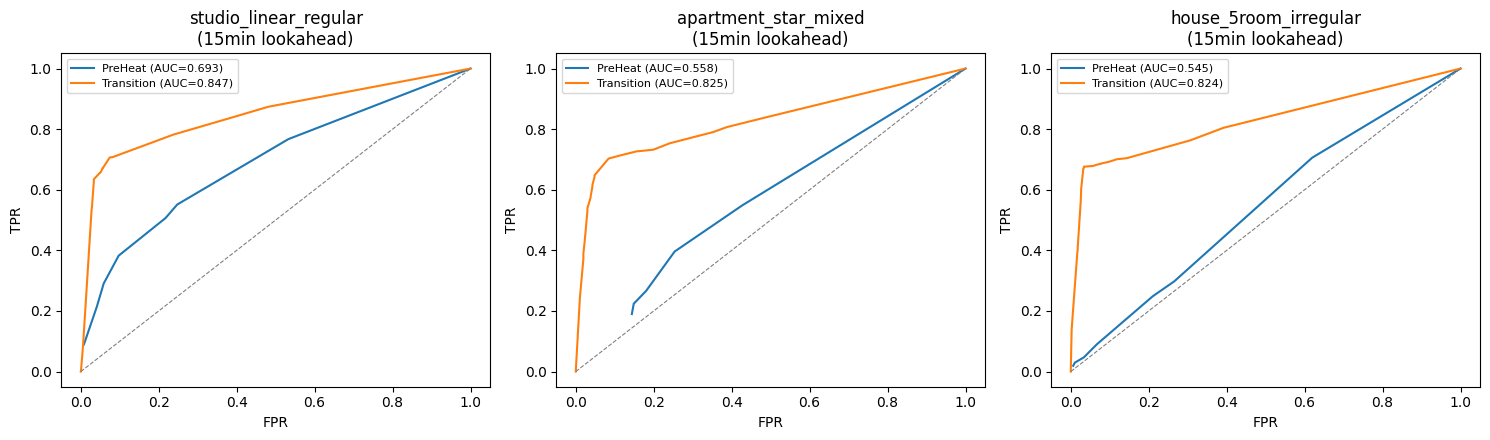

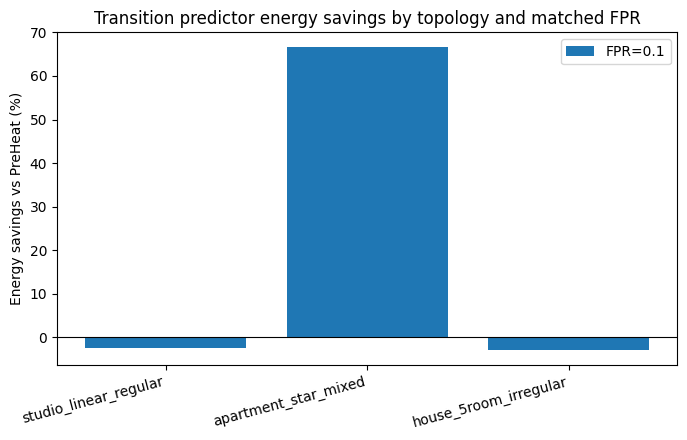

In [15]:
print(f"VERDICT: {verdict}\n")

print(f"{'topology':<25} {'lookahead':>10} {'AUC preheat':>12} {'AUC transition':>16}")
for tr in results:
    for la in LOOKAHEADS:
        b = tr["roc_by_lookahead"][str(la)]["baseline"]["auc"]
        t = tr["roc_by_lookahead"][str(la)]["transition"]["auc"]
        print(f"{tr['topology']:<25} {la:>9}m {b:>12.3f} {t:>16.3f}")

print(f"\n{'FPR':>6} {'mean savings %':>16} {'bootstrap CI95':>24} {'excl. zero':>11} {'missT non-inf':>14}")
for agg in aggregate:
    ci = agg["bootstrap_ci95"]
    print(f"{agg['target_fpr']:>6} {agg['mean_savings_pct']:>16.2f} [{ci[0]:>8.2f}, {ci[1]:>8.2f}]{'':>3} {str(agg['ci_excludes_zero']):>11} {str(agg['miss_time_noninferior']):>14}")

# --- plot: ROC curves (shortest lookahead) per topology ---
la0 = str(LOOKAHEADS[0])
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5), squeeze=False)
for ax, tr in zip(axes[0], results):
    b = tr["roc_by_lookahead"][la0]["baseline"]
    t = tr["roc_by_lookahead"][la0]["transition"]
    ax.plot(b["fpr"], b["tpr"], label=f"PreHeat (AUC={b['auc']:.3f})")
    ax.plot(t["fpr"], t["tpr"], label=f"Transition (AUC={t['auc']:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=0.8)
    ax.set_title(f"{tr['topology']}\n({la0}min lookahead)")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- plot: energy savings % per topology at each matched FPR ---
fig, ax = plt.subplots(figsize=(7, 4.5))
topo_names = [tr["topology"] for tr in results]
x = np.arange(len(topo_names))
width = 0.8 / len(FPR_TARGETS)
for i, agg in enumerate(aggregate):
    ax.bar(x + i * width, agg["per_topology_savings_pct"], width=width, label=f"FPR={agg['target_fpr']}")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + width * (len(FPR_TARGETS) - 1) / 2)
ax.set_xticklabels(topo_names, rotation=15, ha="right")
ax.set_ylabel("Energy savings vs PreHeat (%)")
ax.set_title("Transition predictor energy savings by topology and matched FPR")
ax.legend()
plt.tight_layout()
plt.show()